In [1]:
import torch
from tensorflow.keras.datasets import mnist
# - TensorDataset: Wraps tensors into a dataset that can be indexed (dataset[i] returns the i-th sample)
# - DataLoader: Creates batches of data for training and provides features like shuffling and parallel loading
from torch.utils.data import TensorDataset, DataLoader


# Load the MNIST dataset
# Returns two tuples: (training data, training labels) and (test data, test labels)
# train_images: 60,000 images of shape (28, 28) with pixel values 0-255
# train_labels: 60,000 labels (integers 0-9)
# test_images: 10,000 images for evaluation
# test_labels: 10,000 labels for evaluation
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Convert training images from numpy array to PyTorch tensor
# dtype=torch.float32: Use 32-bit floating point for efficient computation
# / 255.0: Normalize pixel values from range [0, 255] to [0, 1]
# Normalization helps with model convergence and training stability
X_train = torch.tensor(train_images, dtype=torch.float32) / 255.0

# Convert test images to tensor and normalize in the same way
X_test  = torch.tensor(test_images, dtype=torch.float32) / 255.0

# Add channel dimension for CNN compatibility
# CNNs expect input shape: (batch_size, channels, height, width)
# unsqueeze(1) adds a dimension at position 1, converting:
# - From: (60000, 28, 28) → To: (60000, 1, 28, 28)
# The "1" represents grayscale (1 channel). RGB images would have 3 channels
X_train = X_train.unsqueeze(1)   # (N,1,28,28) where N=60000

# Add channel dimension to test images for consistency
X_test  = X_test.unsqueeze(1)

# Convert training labels to PyTorch tensor
# dtype=torch.long: Required for classification tasks (integers for class indices)
# Labels remain as integers 0-9 representing digit classes
y_train = torch.tensor(train_labels, dtype=torch.long)

# Convert test labels to tensor with same dtype
y_test  = torch.tensor(test_labels, dtype=torch.long)


# Set computation device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Create TensorDataset for training data
# TensorDataset pairs features (X_train) with labels (y_train)
# Allows us to access samples as: features, label = train_ds[index]
# This is necessary for DataLoader to batch and iterate over data
train_ds = TensorDataset(X_train, y_train)

# Create TensorDataset for test data (same structure as training dataset)
test_ds  = TensorDataset(X_test, y_test)

# Create DataLoader for training data
# DataLoader provides an iterator that yields batches of data
# Parameters:
# - train_ds: The dataset to load from
# - batch_size=128: Number of samples per batch (larger = faster but more memory)
# - shuffle=True: Randomize sample order each epoch (prevents overfitting to data order)
# - pin_memory=True: Speeds up CPU-to-GPU data transfer by using pinned memory
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, pin_memory=True)

# Create DataLoader for test data
# Parameters:
# - batch_size=256: Larger batch size for testing (no backprop, so uses less memory)
# - shuffle=False: Keep original order for consistent evaluation results
# - pin_memory=True: Optimize memory transfer for faster inference
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, pin_memory=True)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Device: cuda


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        # Call parent class constructor to initialize the module properly
        super().__init__()
        
        # First Convolutional Layer
        # nn.Conv2d(in_channels, out_channels, kernel_size, padding)
        # - in_channels=1: Input is grayscale (1 channel)
        # - out_channels=16: Create 16 feature maps (filters) to detect different patterns
        # - kernel_size=3: Use 3x3 filters to scan the image
        # - padding=1: Add 1 pixel padding around edges to preserve spatial dimensions
        # Output shape: (B, 16, 28, 28) - maintains 28x28 size due to padding
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        
        # Second Convolutional Layer
        # - in_channels=16: Takes output from conv1 (16 channels)
        # - out_channels=32: Create 32 feature maps for more complex pattern detection
        # - kernel_size=3, padding=1: Same as conv1
        # Output shape after this: (B, 32, 28, 28) - size still 28x28
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Max Pooling Layer
        # nn.MaxPool2d(kernel_size) reduces spatial dimensions by taking max value in each window
        # kernel_size=2: Uses 2x2 windows, reduces both height and width by half
        # Example: 28x28 becomes 14x14, 14x14 becomes 7x7
        # Purpose: Reduces computational cost, makes features more robust to small shifts
        self.pool = nn.MaxPool2d(2)
        
        # First Fully Connected (Dense) Layer
        # nn.Linear(in_features, out_features)
        # - in_features=32*14*14=6272: Flattened size of pooled feature maps
        #   (After 2 pooling operations: 28→14→7, but we only pool once after conv2, so 28→14)
        # - out_features=128: Reduce to 128 neurons for pattern combination
        # Purpose: Combine spatial features into abstract representations
        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        
        # Output Layer
        # nn.Linear(128, 10)
        # - in_features=128: Takes 128 features from fc1
        # - out_features=10: Output 10 logits (one for each digit 0-9)
        # Purpose: Produces final predictions (logits) that will be converted to probabilities
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        # Forward pass: defines how data flows through the network
        # Input x shape: (B, 1, 28, 28) where B is batch size
        
        # First convolutional block: conv1 + ReLU activation
        # ReLU (Rectified Linear Unit) = max(0, x) adds non-linearity to learn complex patterns
        # Output shape: (B, 16, 28, 28)
        x = F.relu(self.conv1(x))
        
        # Second convolutional block: conv2 + ReLU activation
        # Output shape: (B, 32, 28, 28)
        x = F.relu(self.conv2(x))
        
        # Max pooling to reduce spatial dimensions
        # Output shape: (B, 32, 14, 14) - height and width halved
        x = self.pool(x)
        
        # Flatten: Convert 4D tensor to 2D tensor for fully connected layers
        # x.size(0) is batch size, -1 means infer remaining dimension
        # Converts (B, 32, 14, 14) → (B, 32*14*14) = (B, 6272)
        # This is necessary because fully connected layers expect 1D input
        x = x.view(x.size(0), -1)
        
        # First fully connected layer + ReLU activation
        # Maps 6272 features down to 128 abstract features
        # Output shape: (B, 128)
        x = F.relu(self.fc1(x))
        
        # Output layer: produces logits (raw scores) for each class
        # NO activation here - CrossEntropyLoss expects raw logits and applies softmax internally
        # Output shape: (B, 10) - 10 scores, one per digit class
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# Loss Function: CrossEntropyLoss
# Combines Softmax (converts logits to probabilities) + Cross-Entropy (measures prediction error)
# - Softmax: Converts 10 logits → 10 probabilities that sum to 1
# - Cross-Entropy: Measures how far predicted probabilities are from true labels (0 or 1)
# Why use it: Numerically stable (combines operations efficiently), standard for classification
criterion = nn.CrossEntropyLoss()

# Optimizer: SGD (Stochastic Gradient Descent)
# Updates model weights to minimize loss during backpropagation
# Parameters:
# - model.parameters(): All trainable weights in the model
# - lr=0.1: Learning rate - how big each update step is (0.1 = 10% step)
#   Too high: May overshoot and diverge
#   Too low: Trains slowly, may get stuck
# - momentum=0.9: Acceleration factor for optimization
#   Helps navigate flat regions and accelerates learning
#   Accumulates previous gradients to build momentum (90% of previous update)
#   Similar to a ball rolling downhill - gains speed in consistent direction
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)


In [ ]:
# Decorator: @torch.no_grad() disables gradient computation
# Why: During evaluation, we don't need gradients (no backprop), saves memory and speeds up
@torch.no_grad()
def evaluate(model, loader):
    """
    Evaluate model performance on a dataset without updating weights.
    Returns average loss and accuracy.
    """
    # Set model to evaluation mode
    # - Disables dropout (data augmentation layer that randomly removes neurons during training)
    # - Uses running statistics for batch normalization (if present) instead of batch statistics
    # - Makes model deterministic (same input = same output)
    model.eval()
    
    # Accumulators for metrics
    total_loss = 0.0  # Sum of all losses
    correct = 0       # Count of correct predictions
    total = 0         # Total number of samples

    # Iterate through batches from the loader
    for x, y in loader:
        # Move data to the computation device (GPU if available, CPU otherwise)
        # non_blocking=True: Asynchronously transfer data for speed (CPU can prepare next batch)
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Forward pass: get model predictions (logits)
        # logits shape: (batch_size, 10) - raw scores for each digit
        logits = model(x)
        
        # Calculate loss: how wrong are the predictions?
        # Applies softmax internally, then compares to true labels
        loss = criterion(logits, y)

        # Accumulate total loss (multiply by batch size to get sum, not average)
        # loss.item() converts tensor to Python float
        total_loss += loss.item() * y.size(0)
        
        # Get predicted class: argmax finds which logit is highest (most confident prediction)
        # dim=1 means find max across the 10 classes (not across batch)
        # preds shape: (batch_size,) - single prediction per sample
        preds = logits.argmax(dim=1)
        
        # Count correct predictions: compare to true labels
        # (preds == y) creates boolean tensor, .sum() counts True values
        # .item() converts count to Python int
        correct += (preds == y).sum().item()
        
        # Track total number of samples processed
        total += y.size(0)

    # Return average loss and accuracy
    # Average loss: total_loss / total_samples
    # Accuracy: correct_predictions / total_predictions (as decimal, e.g., 0.95 = 95%)
    return total_loss / total, correct / total


def train_one_epoch(model, loader):
    """
    Train model for one full pass through the training data.
    Updates weights using backpropagation. Returns average loss.
    """
    # Set model to training mode
    # - Enables dropout (randomly disables neurons to prevent overfitting)
    # - Uses batch statistics for batch normalization (if present)
    # - Makes training stochastic (introduces randomness to improve generalization)
    model.train()
    
    # Accumulator for total loss
    total_loss = 0.0

    # Iterate through batches
    for x, y in loader:
        # Move batch to device (CPU or GPU)
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Step 1: Clear old gradients
        # optimizer.zero_grad() is required before backprop
        # Why: PyTorch accumulates gradients by default, we don't want to mix old and new
        optimizer.zero_grad()
        
        # Step 2: Forward pass - compute predictions
        logits = model(x)  # Shape: (batch_size, 10)
        
        # Step 3: Calculate loss
        loss = criterion(logits, y)

        # Step 4: Backward pass - compute gradients
        # loss.backward() computes ∂loss/∂parameter for all model weights
        # Uses chain rule to propagate error signal backward through network
        loss.backward()
        
        # Step 5: Update weights
        # optimizer.step() adjusts weights in direction opposite to gradients
        # Formula: weight -= learning_rate * gradient (simplified, momentum makes it more complex)
        optimizer.step()

        # Accumulate loss for this batch
        total_loss += loss.item() * y.size(0)

    # Return average loss across all training samples
    return total_loss / len(loader.dataset)


In [ ]:
# Training Loop: Main training process
# Define number of epochs: how many times to iterate through entire training dataset
# More epochs = more learning (up to a point), can lead to overfitting if too many
epochs = 5

# Loop through each epoch
# range(1, epochs + 1) gives [1, 2, 3, 4, 5] for epochs=5
for epoch in range(1, epochs + 1):
    # Train for one epoch: forward pass, backward pass, update weights on all training data
    train_loss = train_one_epoch(model, train_loader)
    
    # Evaluate on test set: measure how well model generalizes to unseen data
    # Get both loss and accuracy
    test_loss, test_acc = evaluate(model, test_loader)
    
    # Print progress: human-readable training metrics
    # Format: Epoch 01 | train loss 0.2345 | test loss 0.1234 | test acc 0.9567 (95.67% accuracy)
    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} | test loss {test_loss:.4f} | test acc {test_acc:.4f}")


Epoch 01 | train loss 0.2842 | test loss 0.0667 | test acc 0.9792
Epoch 02 | train loss 0.0572 | test loss 0.0555 | test acc 0.9832
Epoch 03 | train loss 0.0386 | test loss 0.0439 | test acc 0.9863
Epoch 04 | train loss 0.0286 | test loss 0.0457 | test acc 0.9871
Epoch 05 | train loss 0.0188 | test loss 0.0517 | test acc 0.9866



MODEL ARCHITECTURE SUMMARY
SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

TOTAL MODEL PARAMETERS
Total trainable parameters: 809,034
conv1.weight: 144 parameters | shape: torch.Size([16, 1, 3, 3])
conv1.bias: 16 parameters | shape: torch.Size([16])
conv2.weight: 4,608 parameters | shape: torch.Size([32, 16, 3, 3])
conv2.bias: 32 parameters | shape: torch.Size([32])
fc1.weight: 802,816 parameters | shape: torch.Size([128, 6272])
fc1.bias: 128 parameters | shape: torch.Size([128])
fc2.weight: 1,280 parameters | shape: torch.Size([10, 128])
fc2.bias: 10 parameters | shape: torch.Size([10])

GENERATING PREDICTIONS FOR ANALYSIS...
Processed 10000 test samples


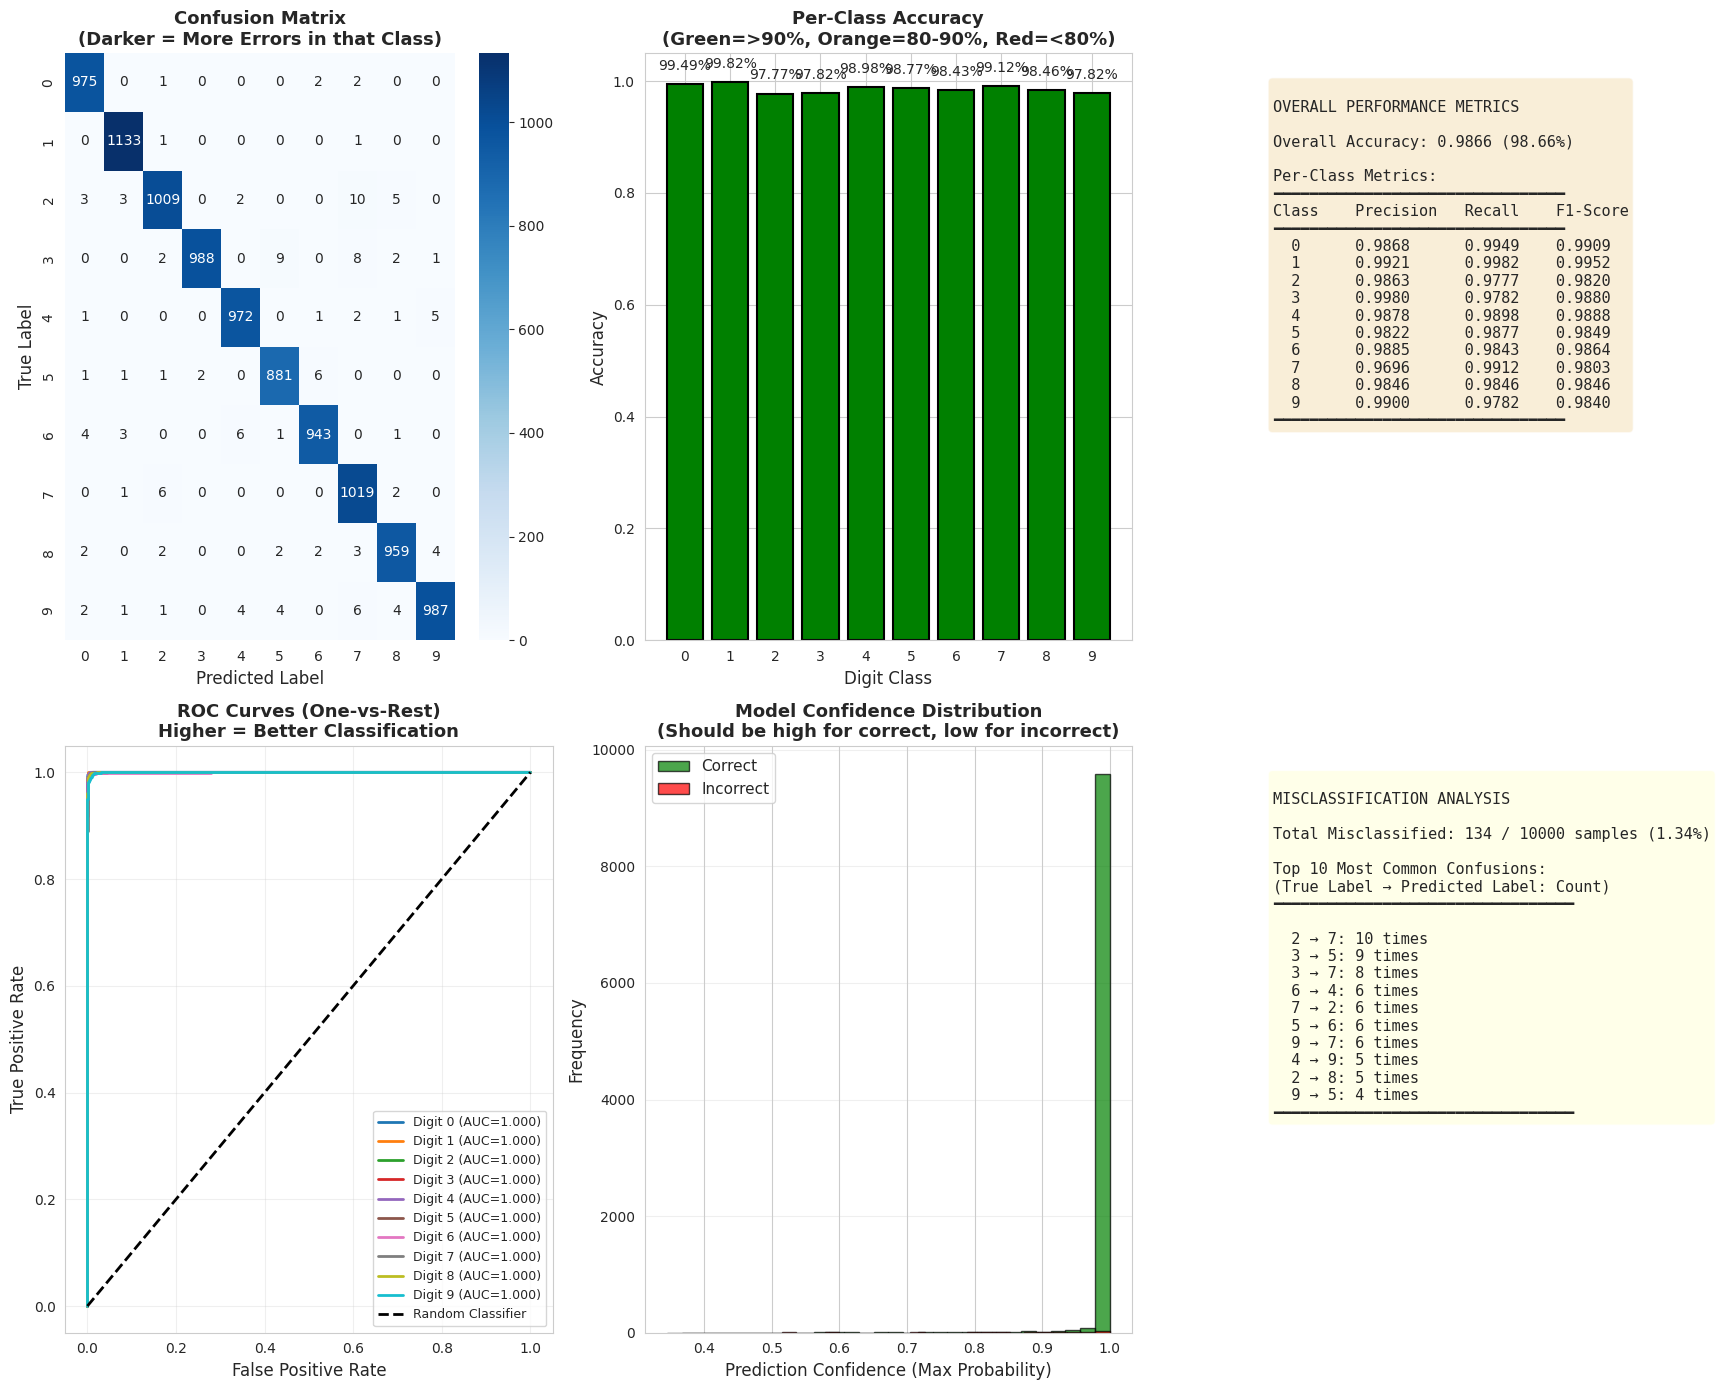


VISUALIZATION COMPLETE


In [6]:
# ============================================
# MODEL ANALYSIS AND VISUALIZATION
# ============================================

# Import visualization and metrics libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
import numpy as np

# Configure plot style for better looking visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# ==============================================================================
# 1. DISPLAY MODEL ARCHITECTURE
# ==============================================================================
print("\n" + "="*80)
print("MODEL ARCHITECTURE SUMMARY")
print("="*80)
print(model)
print("\n" + "="*80)
print("TOTAL MODEL PARAMETERS")
print("="*80)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# Count parameters per layer
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.numel():,} parameters | shape: {param.shape}")


# ==============================================================================
# 2. GENERATE PREDICTIONS ON TEST SET FOR METRICS
# ==============================================================================
print("\n" + "="*80)
print("GENERATING PREDICTIONS FOR ANALYSIS...")
print("="*80)

# Lists to store all predictions and true labels
all_preds = []      # Predicted class labels (0-9)
all_labels = []     # True class labels
all_probs = []      # Predicted probabilities for all classes (for ROC-AUC)

# Set model to evaluation mode and disable gradients
model.eval()
with torch.no_grad():
    # Iterate through test set
    for x, y in test_loader:
        # Move to device
        x = x.to(device)
        y = y.to(device)
        
        # Get predictions (logits)
        logits = model(x)
        
        # Get predicted classes (argmax of logits)
        preds = logits.argmax(dim=1)
        
        # Get probabilities (softmax of logits)
        probs = torch.nn.functional.softmax(logits, dim=1)
        
        # Store results (convert to CPU and numpy for sklearn compatibility)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print(f"Processed {len(all_labels)} test samples")


# ==============================================================================
# 3. CREATE COMPREHENSIVE VISUALIZATION
# ==============================================================================
fig = plt.figure(figsize=(18, 14))

# -------- SUBPLOT 1: CONFUSION MATRIX --------
# Confusion matrix shows true vs predicted for each class
# Diagonal = correct predictions, off-diagonal = misclassifications
cm = confusion_matrix(all_labels, all_preds)

ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax1,
            xticklabels=range(10), yticklabels=range(10))
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_title('Confusion Matrix\n(Darker = More Errors in that Class)', fontsize=13, fontweight='bold')


# -------- SUBPLOT 2: PER-CLASS ACCURACY --------
# Calculate accuracy for each digit class separately
class_accuracy = []
for i in range(10):
    # Find indices where true label is i
    class_mask = all_labels == i
    if class_mask.sum() > 0:
        # Calculate accuracy: correct predictions / total predictions for class i
        accuracy = (all_preds[class_mask] == all_labels[class_mask]).sum() / class_mask.sum()
        class_accuracy.append(accuracy)
    else:
        class_accuracy.append(0)

ax2 = plt.subplot(2, 3, 2)
colors = ['green' if acc > 0.9 else 'orange' if acc > 0.8 else 'red' for acc in class_accuracy]
bars = ax2.bar(range(10), class_accuracy, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Digit Class', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Per-Class Accuracy\n(Green=>90%, Orange=80-90%, Red=<80%)', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.set_xticks(range(10))
# Add percentage labels on bars
for i, (bar, acc) in enumerate(zip(bars, class_accuracy)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=10)


# -------- SUBPLOT 3: OVERALL METRICS --------
# Calculate overall accuracy and other metrics
overall_accuracy = (all_preds == all_labels).sum() / len(all_labels)

ax3 = plt.subplot(2, 3, 3)
ax3.axis('off')

# Display key metrics as text
metrics_text = f"""
OVERALL PERFORMANCE METRICS

Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)

Per-Class Metrics:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Class    Precision   Recall    F1-Score
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"""

# Generate detailed classification report
report = classification_report(all_labels, all_preds, digits=4, output_dict=True)

# Add per-class metrics to display
for digit in range(10):
    prec = report[str(digit)]['precision']
    recall = report[str(digit)]['recall']
    f1 = report[str(digit)]['f1-score']
    metrics_text += f"\n  {digit}      {prec:.4f}      {recall:.4f}    {f1:.4f}"

metrics_text += f"\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"

ax3.text(0.1, 0.95, metrics_text, transform=ax3.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


# -------- SUBPLOT 4: ROC CURVES (One-vs-Rest) --------
# ROC curve shows trade-off between true positive rate and false positive rate
# AUC (Area Under Curve) score: 1.0 = perfect, 0.5 = random guessing
ax4 = plt.subplot(2, 3, 4)

# Plot ROC curve for each digit (one-vs-rest approach)
for digit in range(10):
    # Create binary labels: 1 if digit matches, 0 otherwise
    binary_labels = (all_labels == digit).astype(int)
    
    # Get probabilities for this digit (from the softmax output)
    digit_probs = all_probs[:, digit]
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(binary_labels, digit_probs)
    
    # Calculate AUC (area under curve)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve for this digit
    ax4.plot(fpr, tpr, label=f'Digit {digit} (AUC={roc_auc:.3f})', linewidth=2)

# Add diagonal line (represents random classifier)
ax4.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
ax4.set_xlabel('False Positive Rate', fontsize=12)
ax4.set_ylabel('True Positive Rate', fontsize=12)
ax4.set_title('ROC Curves (One-vs-Rest)\nHigher = Better Classification', fontsize=13, fontweight='bold')
ax4.legend(loc='lower right', fontsize=9)
ax4.grid(True, alpha=0.3)


# -------- SUBPLOT 5: CONFIDENCE DISTRIBUTION --------
# Shows how confident the model is in its predictions
# High confidence for correct predictions = good model behavior
max_probs = all_probs.max(axis=1)  # Maximum probability for each sample
correct_mask = all_preds == all_labels

ax5 = plt.subplot(2, 3, 5)
# Plot histogram of confidence for correct vs incorrect predictions
ax5.hist(max_probs[correct_mask], bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
ax5.hist(max_probs[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
ax5.set_xlabel('Prediction Confidence (Max Probability)', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title('Model Confidence Distribution\n(Should be high for correct, low for incorrect)', fontsize=13, fontweight='bold')
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3, axis='y')


# -------- SUBPLOT 6: MISCLASSIFICATION ANALYSIS --------
# Shows which classes are confused most often
misclassified_mask = all_preds != all_labels
misclassified_count = np.sum(misclassified_mask)

ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

misclass_text = f"""
MISCLASSIFICATION ANALYSIS

Total Misclassified: {misclassified_count} / {len(all_labels)} samples ({misclassified_count/len(all_labels)*100:.2f}%)

Top 10 Most Common Confusions:
(True Label → Predicted Label: Count)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

# Find most common confusions
confusion_pairs = {}
for true_label, pred_label in zip(all_labels[misclassified_mask], all_preds[misclassified_mask]):
    pair = (true_label, pred_label)
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# Sort by frequency (most common first)
sorted_confusions = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

for (true_label, pred_label), count in sorted_confusions:
    misclass_text += f"\n  {true_label} → {pred_label}: {count} times"

misclass_text += f"\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"

ax6.text(0.1, 0.95, misclass_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))


plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)



VISUALIZING CNN FILTERS - LEARNED FEATURE DETECTORS

First Convolutional Layer (conv1): 16 filters
Each filter detects different low-level features (edges, textures, etc.)
Conv1 weights shape: torch.Size([16, 1, 3, 3])


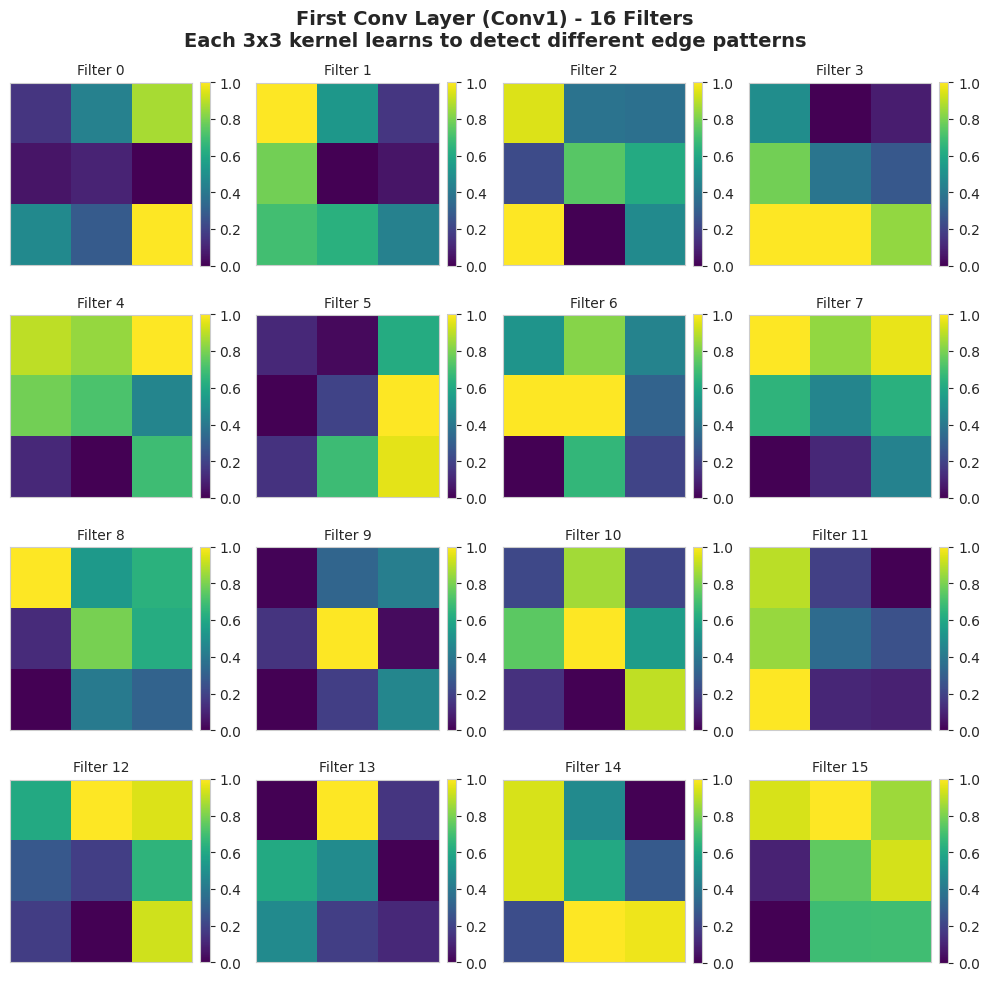


First Conv Layer Filter Statistics:
  Filter value range: [-1.3380, 1.0442]
  Mean filter value: -0.1104
  Standard deviation: 0.4525

--------------------------------------------------------------------------------

Second Convolutional Layer (conv2): 32 filters
Each filter builds on conv1 outputs to detect mid-level features (shapes, patterns)
Conv2 weights shape: torch.Size([32, 16, 3, 3])


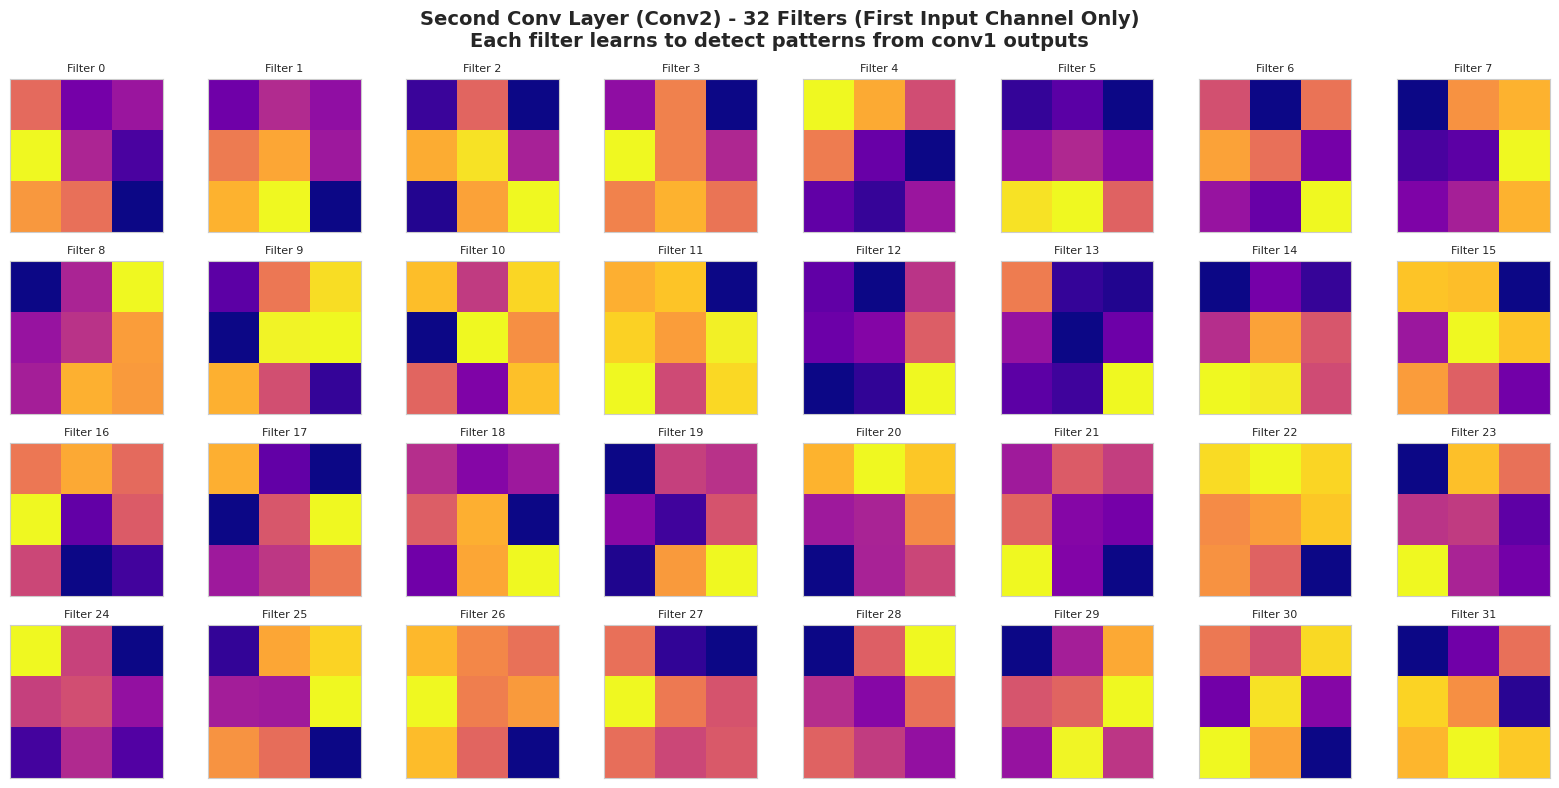


Second Conv Layer Filter Statistics:
  Filter value range: [-0.8830, 0.7349]
  Mean filter value: -0.0366
  Standard deviation: 0.1185

--------------------------------------------------------------------------------

Visualizing Filter Activations on Sample Test Image
Shows what each filter learns to detect
Conv1 activation shape: torch.Size([16, 28, 28])


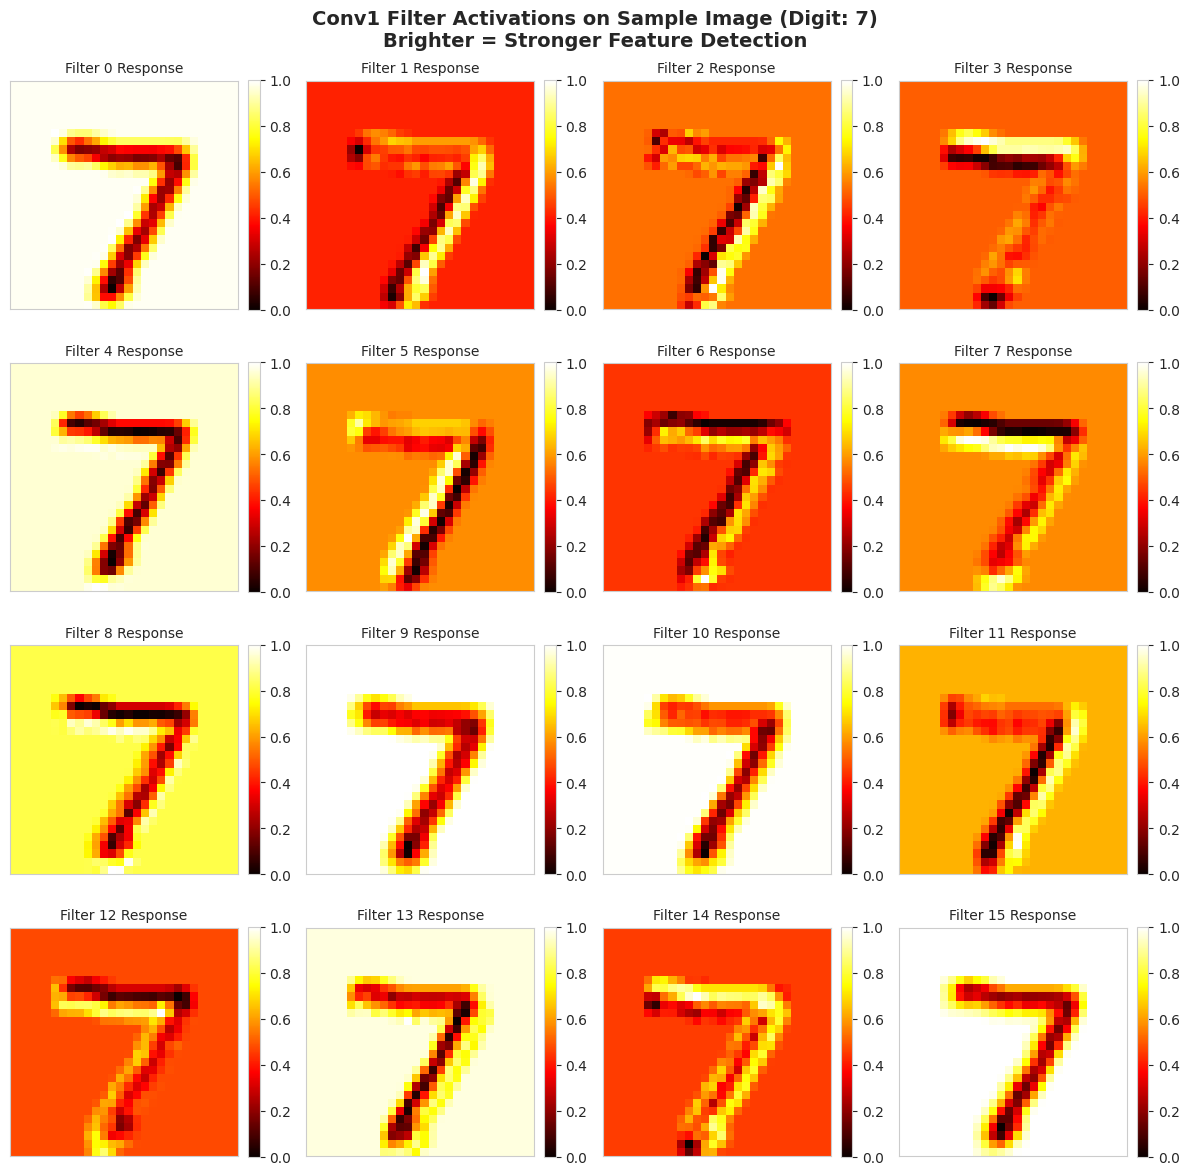

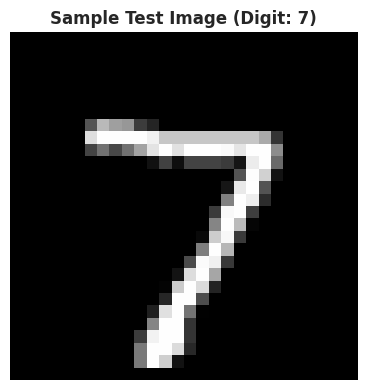


--------------------------------------------------------------------------------

Comparing Filter Responses Across Different Digits


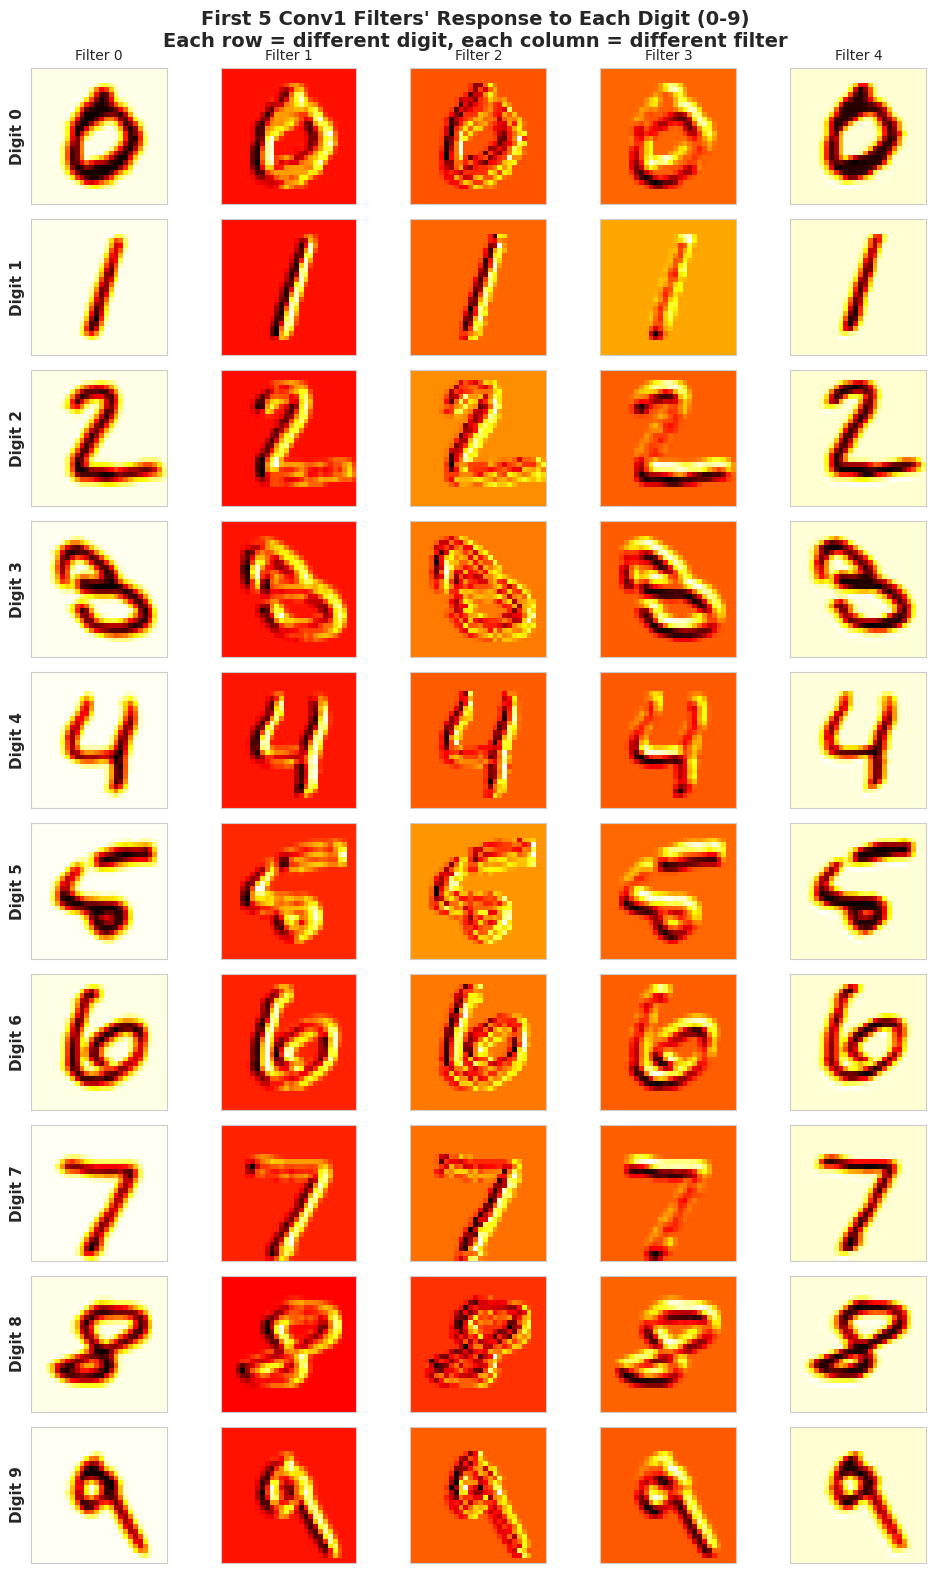


CNN FILTER VISUALIZATION COMPLETE

KEY INSIGHTS:
- First layer filters learn simple patterns: edges, curves, corners
- Second layer filters learn complex patterns: shapes, digit parts
- Bright regions in activation maps = strong feature detection
- Different digits activate different filters
- This shows how CNN learns hierarchical feature representations



In [8]:
# ============================================
# CNN FILTER VISUALIZATION
# ============================================
# This section visualizes the learned filters (kernels) from the convolutional layers
# Filters are the small matrices that scan the image to detect features like edges, corners, etc.

print("\n" + "="*80)
print("VISUALIZING CNN FILTERS - LEARNED FEATURE DETECTORS")
print("="*80)

# ==============================================================================
# 1. EXTRACT AND VISUALIZE FIRST CONVOLUTIONAL LAYER FILTERS
# ==============================================================================
print("\nFirst Convolutional Layer (conv1): 16 filters")
print("Each filter detects different low-level features (edges, textures, etc.)")

# Extract weights from first convolutional layer
# conv1 shape: (out_channels, in_channels, kernel_height, kernel_width)
# (16, 1, 3, 3) = 16 filters, each 3x3, for 1 input channel
conv1_weights = model.conv1.weight.data.cpu()  # Move to CPU for visualization
print(f"Conv1 weights shape: {conv1_weights.shape}")

# Create figure for first layer filters
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('First Conv Layer (Conv1) - 16 Filters\nEach 3x3 kernel learns to detect different edge patterns',
             fontsize=14, fontweight='bold')

# Iterate through all 16 filters
for i in range(16):
    # Get i-th filter: shape (1, 3, 3) - single channel, 3x3
    filter_2d = conv1_weights[i, 0, :, :].numpy()
    
    # Normalize filter values to [0, 1] range for better visualization
    # Why: Makes contrasts visible; raw values might be too small/large
    filter_normalized = (filter_2d - filter_2d.min()) / (filter_2d.max() - filter_2d.min() + 1e-8)
    
    # Plot filter as heatmap
    ax = axes[i // 4, i % 4]
    im = ax.imshow(filter_normalized, cmap='viridis', interpolation='nearest')
    ax.set_title(f'Filter {i}', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add colorbar for each filter to show value range
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Print statistics about first layer filters
print("\nFirst Conv Layer Filter Statistics:")
print(f"  Filter value range: [{conv1_weights.min():.4f}, {conv1_weights.max():.4f}]")
print(f"  Mean filter value: {conv1_weights.mean():.4f}")
print(f"  Standard deviation: {conv1_weights.std():.4f}")


# ==============================================================================
# 2. EXTRACT AND VISUALIZE SECOND CONVOLUTIONAL LAYER FILTERS
# ==============================================================================
print("\n" + "-"*80)
print("\nSecond Convolutional Layer (conv2): 32 filters")
print("Each filter builds on conv1 outputs to detect mid-level features (shapes, patterns)")

# Extract weights from second convolutional layer
# conv2 shape: (out_channels, in_channels, kernel_height, kernel_width)
# (32, 16, 3, 3) = 32 filters, each takes 16 input channels, kernel is 3x3
conv2_weights = model.conv2.weight.data.cpu()
print(f"Conv2 weights shape: {conv2_weights.shape}")

# Create figure for second layer filters (visualize filters from first input channel)
# Since conv2 has 16 input channels, we visualize the first channel of each filter
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Second Conv Layer (Conv2) - 32 Filters (First Input Channel Only)\nEach filter learns to detect patterns from conv1 outputs',
             fontsize=14, fontweight='bold')

# Iterate through all 32 filters
for i in range(32):
    # Get i-th filter's first input channel: shape (1, 3, 3)
    # This shows how the filter responds to the first feature map from conv1
    filter_2d = conv2_weights[i, 0, :, :].numpy()
    
    # Normalize for visualization
    filter_normalized = (filter_2d - filter_2d.min()) / (filter_2d.max() - filter_2d.min() + 1e-8)
    
    # Plot filter as heatmap
    ax = axes[i // 8, i % 8]
    im = ax.imshow(filter_normalized, cmap='plasma', interpolation='nearest')
    ax.set_title(f'Filter {i}', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Print statistics about second layer filters
print("\nSecond Conv Layer Filter Statistics:")
print(f"  Filter value range: [{conv2_weights.min():.4f}, {conv2_weights.max():.4f}]")
print(f"  Mean filter value: {conv2_weights.mean():.4f}")
print(f"  Standard deviation: {conv2_weights.std():.4f}")


# ==============================================================================
# 3. VISUALIZE FILTER ACTIVATION ON SAMPLE IMAGE
# ==============================================================================
print("\n" + "-"*80)
print("\nVisualizing Filter Activations on Sample Test Image")
print("Shows what each filter learns to detect")

# Get a sample image from test set
sample_image = test_images[0]  # Shape: (28, 28)
sample_label = test_labels[0]

# Convert to tensor and normalize
sample_tensor = torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
sample_tensor = sample_tensor.to(device)

# Extract features from first convolutional layer
# Register hook to capture intermediate activations
conv1_output = None

def hook_conv1(module, input, output):
    global conv1_output
    conv1_output = output.detach()

# Register hook to capture conv1 output
hook_handle = model.conv1.register_forward_hook(hook_conv1)

# Forward pass to generate activations
with torch.no_grad():
    _ = model(sample_tensor)

# Remove hook
hook_handle.remove()

# Extract and visualize activations from conv1
conv1_activations = conv1_output[0].cpu()  # Shape: (16, 28, 28)
print(f"Conv1 activation shape: {conv1_activations.shape}")

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle(f'Conv1 Filter Activations on Sample Image (Digit: {sample_label})\nBrighter = Stronger Feature Detection',
             fontsize=14, fontweight='bold')

# Visualize activation for each filter
for i in range(16):
    # Get activation map for i-th filter
    activation_map = conv1_activations[i].numpy()
    
    # Normalize activation for visualization
    activation_normalized = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min() + 1e-8)
    
    # Plot activation heatmap
    ax = axes[i // 4, i % 4]
    im = ax.imshow(activation_normalized, cmap='hot', interpolation='nearest')
    ax.set_title(f'Filter {i} Response', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Also visualize the original sample image
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(sample_image, cmap='gray')
ax.set_title(f'Sample Test Image (Digit: {sample_label})', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


# ==============================================================================
# 4. VISUALIZE FILTER RESPONSES ACROSS MULTIPLE SAMPLES
# ==============================================================================
print("\n" + "-"*80)
print("\nComparing Filter Responses Across Different Digits")

# Select one sample of each digit class
sample_indices = []
for digit in range(10):
    idx = np.where(test_labels == digit)[0][0]  # First occurrence of each digit
    sample_indices.append(idx)

fig, axes = plt.subplots(10, 5, figsize=(10, 16))
fig.suptitle('First 5 Conv1 Filters\' Response to Each Digit (0-9)\nEach row = different digit, each column = different filter',
             fontsize=14, fontweight='bold')

# For each digit class
for digit_idx, sample_idx in enumerate(sample_indices):
    sample_image = test_images[sample_idx]
    sample_label = test_labels[sample_idx]
    
    # Convert to tensor
    sample_tensor = torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
    sample_tensor = sample_tensor.to(device)
    
    # Get conv1 activations
    conv1_output = None
    hook_handle = model.conv1.register_forward_hook(hook_conv1)
    with torch.no_grad():
        _ = model(sample_tensor)
    hook_handle.remove()
    
    conv1_activations = conv1_output[0].cpu()
    
    # Visualize first 5 filters only (for space)
    for filter_idx in range(5):
        activation_map = conv1_activations[filter_idx].numpy()
        activation_normalized = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min() + 1e-8)
        
        ax = axes[digit_idx, filter_idx]
        ax.imshow(activation_normalized, cmap='hot', interpolation='nearest')
        
        if filter_idx == 0:
            ax.set_ylabel(f'Digit {sample_label}', fontsize=11, fontweight='bold')
        if digit_idx == 0:
            ax.set_title(f'Filter {filter_idx}', fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


print("\n" + "="*80)
print("CNN FILTER VISUALIZATION COMPLETE")
print("="*80)
print("""
KEY INSIGHTS:
- First layer filters learn simple patterns: edges, curves, corners
- Second layer filters learn complex patterns: shapes, digit parts
- Bright regions in activation maps = strong feature detection
- Different digits activate different filters
- This shows how CNN learns hierarchical feature representations
""")
